### SHAP Interpretability

In [1]:
import pandas as pd
import numpy as np
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os

data_processed = os.path.expanduser("~/Pan-Autoimmune-miRNA-ML/data/processed")
print("Libraries loaded")

Libraries loaded


In [2]:
## Load feature matrix and train Random Forest for SHAP analysis
## Using Random Forest as it is most compatible with SHAP TreeExplainer

data = pd.read_csv(f"{data_processed}/ML_feature_matrix.csv", index_col=0)

X = data.drop(columns=['disease_label'])
y = data['disease_label']

## Train/test split for SHAP — we explain predictions on held-out test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Test accuracy: {rf.score(X_test, y_test):.3f}")

Training samples: 335
Test samples: 84
Test accuracy: 0.988


In [3]:
## Calculate SHAP values using TreeExplainer
## TreeExplainer is optimized for tree-based models like Random Forest

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {np.array(shap_values).shape}")
print("SHAP calculation complete")

SHAP values shape: (84, 500, 4)
SHAP calculation complete


In [4]:
## Extract top SHAP genes per disease class
## class order: 0=RA, 1=SLE, 2=T1D, 3=Vitiligo

class_names = ['RA', 'SLE', 'T1D', 'Vitiligo']

top_shap_genes = {}
for i, disease in enumerate(class_names):
    shap_vals = np.abs(shap_values[:, :, i]).mean(axis=0)
    top_idx = np.argsort(shap_vals)[::-1][:20]
    top_genes = X_test.columns[top_idx].tolist()
    top_shap_genes[disease] = top_genes
    print(f"\n{disease} top 5 genes: {top_genes[:5]}")


RA top 5 genes: ['SFN', 'S100A16', 'SNRPE', 'GRHL2', 'FXYD3']

SLE top 5 genes: ['SFN', 'S100A16', 'FXYD3', 'GRHL2', 'SNRPE']

T1D top 5 genes: ['TCEAL8', 'GTF2F2', 'COX6C', 'PFDN5', 'GNL3']

Vitiligo top 5 genes: ['SERPINB5', 'GPR115', 'LCE3D', 'LYPD3', 'PFN2']


In [5]:
## Save top SHAP genes per disease
for disease, genes in top_shap_genes.items():
    pd.DataFrame(genes, columns=['gene']).to_csv(
        f"{data_processed}/{disease}_top_SHAP_genes.csv", index=False)
print("SHAP gene lists saved")

SHAP gene lists saved


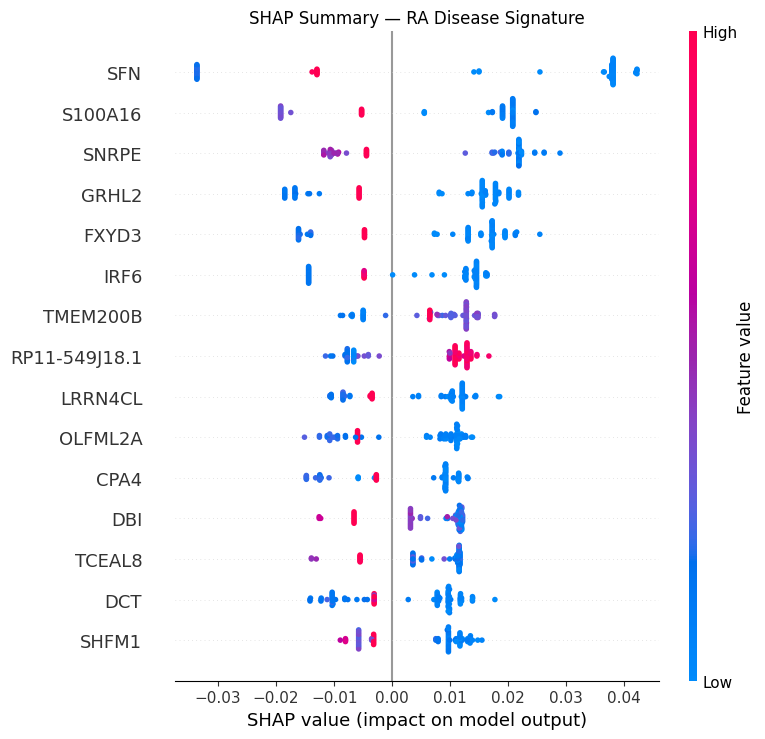

SHAP summary plot saved


In [6]:
import shap
import matplotlib.pyplot as plt
import os

figures_path = os.path.expanduser("~/Pan-Autoimmune-miRNA-ML/results/figures")

## SHAP summary plot for RA class (most samples, most reliable)
shap.summary_plot(
    shap_values[:, :, 0],
    X_test,
    max_display=15,
    show=False,
    plot_type="dot"
)
plt.title("SHAP Summary — RA Disease Signature")
plt.tight_layout()
plt.savefig(f"{figures_path}/SHAP_summary_RA.png", dpi=300, bbox_inches='tight')
plt.show()
print("SHAP summary plot saved")